# Logistic Regression

This notebook reproduces the **Logistic Regression** example from Christoph Molnar's *Interpretable Machine Learning*.

The goal is not only to build a binary classification model, but also to understand how logistic regression can be interpreted through:

- model coefficients and standard errors
- odds ratios
- p-values and confidence intervals
- individual prediction contributions
- ROC-AUC
- calibration
- Brier score

The example predicts whether a **Chinstrap penguin is female** using bill measurements, flipper length, and the categorical `chonkiness` feature.

## 1. Setup

Import the libraries used throughout the experiment and load the Palmer Penguins dataset.

In [2]:
# Import librarires and Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    brier_score_loss,
)
from sklearn.calibration import calibration_curve

# Load the Palmer Penguins dataset
penguins = pd.read_csv("data/penguins.csv")

print(penguins.head())
print("Dataset shape:", penguins.shape)
print("Columns:", penguins.columns.tolist())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  year  
0       3750.0    male  2007  
1       3800.0  female  2007  
2       3250.0  female  2007  
3          NaN     NaN  2007  
4       3450.0  female  2007  
Dataset shape: (344, 8)
Columns: ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex', 'year']


## 2. Data Preparation

The dataset contains some missing values. Because the model requires complete observations for the variables used here, remove rows containing missing values.

We also inspect the distribution of the target variable, `sex`.

Missing values:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

Cleaned dataset shape: (333, 8)

Sex distribution:
sex
male      168
female    165
Name: count, dtype: int64


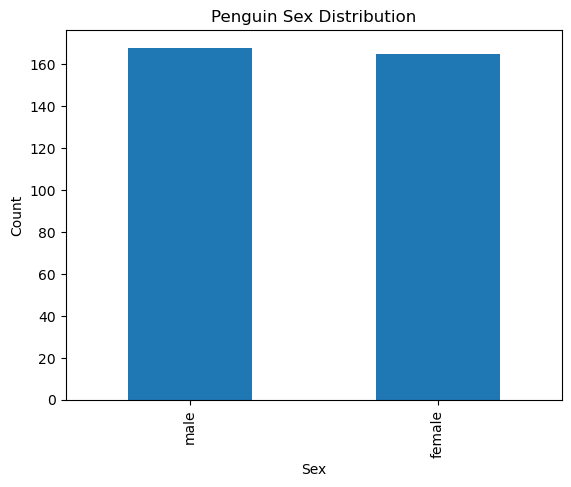

In [3]:
# Check for missing values and remove incomplete observations
print("Missing values:")
print(penguins.isna().sum())

penguins = penguins.dropna().copy()

print("\nCleaned dataset shape:", penguins.shape)
print("\nSex distribution:")
print(penguins["sex"].value_counts())

penguins["sex"].value_counts().plot(
    kind="bar",
    title="Penguin Sex Distribution"
)
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

## 3. Select Chinstrap Penguins

Molnar's example focuses on **Chinstrap penguins**. We therefore restrict the dataset to this species before constructing the model.

In [4]:
# Select Chinstrap penguins
chinstrap = penguins[penguins["species"] == "Chinstrap"].copy()

print("Number of Chinstrap penguins:", len(chinstrap))
print("\nSex distribution:")
print(chinstrap["sex"].value_counts())

Number of Chinstrap penguins: 68

Sex distribution:
sex
female    34
male      34
Name: count, dtype: int64


## 4. Create the `chonkiness` Feature

For this example, `chonkiness` is a categorical version of `body_mass_g`.

- Lowest 25% → `Smol_Penguin`
- Middle 50% → `Regular_Penguin`
- Highest 25% → `Absolute_Unit`

This discretization is used to demonstrate how logistic regression handles categorical predictors. It also loses some information from the original continuous body-mass variable, so it should not automatically be treated as a better feature engineering choice.

In [5]:
# Define the 25th and 75th percentiles of body mass
q1 = chinstrap["body_mass_g"].quantile(0.25)
q3 = chinstrap["body_mass_g"].quantile(0.75)

# Convert body mass into three categorical groups
chinstrap["chonkiness"] = pd.cut(
    chinstrap["body_mass_g"],
    bins=[-np.inf, q1, q3, np.inf],
    labels=[
        "Smol_Penguin",
        "Regular_Penguin",
        "Absolute_Unit",
    ],
)

print("Body-mass cut points:")
print("Q1:", q1)
print("Q3:", q3)

print("\nChonkiness distribution:")
print(chinstrap["chonkiness"].value_counts())

Body-mass cut points:
Q1: 3487.5
Q3: 3950.0

Chonkiness distribution:
chonkiness
Regular_Penguin    35
Smol_Penguin       17
Absolute_Unit      16
Name: count, dtype: int64


In [6]:
# Inspect the newly created categorical feature
chinstrap[
    ["body_mass_g", "chonkiness", "sex"]
].head(10)

,body_mass_g,chonkiness,sex
276,3500.0,Regular_Penguin,female
277,3900.0,Regular_Penguin,male
278,3650.0,Regular_Penguin,male
279,3525.0,Regular_Penguin,female
280,3725.0,Regular_Penguin,male
281,3950.0,Regular_Penguin,female
282,3250.0,Smol_Penguin,female
283,3750.0,Regular_Penguin,male
284,4150.0,Absolute_Unit,female
285,3700.0,Regular_Penguin,male


## 5. Encode the Target and Categorical Predictor

The target is converted to binary form:

- `1` → female
- `0` → male

For `chonkiness`, one-hot encoding is used with `Smol_Penguin` as the reference category. Therefore, the model estimates the effect of `Regular_Penguin` and `Absolute_Unit` relative to `Smol_Penguin`.

In [7]:
# Encode the binary target
chinstrap["female"] = (chinstrap["sex"] == "female").astype(int)

# One-hot encode chonkiness, keeping Smol_Penguin as the reference category
chonkiness_dummies = pd.get_dummies(
    chinstrap["chonkiness"],
    drop_first=True,
    dtype=int,
)

# Build the feature matrix
X = pd.concat(
    [
        chinstrap[
            [
                "bill_depth_mm",
                "bill_length_mm",
                "flipper_length_mm",
            ]
        ],
        chonkiness_dummies,
    ],
    axis=1,
)

y = chinstrap["female"]

print("Features:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

Features:
['bill_depth_mm', 'bill_length_mm', 'flipper_length_mm', 'Regular_Penguin', 'Absolute_Unit']

Target distribution:
female
1    34
0    34
Name: count, dtype: int64


## 6. Fit the Logistic Regression Model

Logistic regression models the probability of the positive class through the logistic function:

$$\text{P(Y=1)} = \frac{1}{1 + e^{-z}}$$


where

$$\text{z} = {\beta_0 + \beta_1x_1 + \cdots + \beta_px_p}$$

The coefficients are therefore linear effects on **log-odds**, not direct changes in probability.

`statsmodels.Logit` is used here because it provides the coefficient estimates and standard errors needed for interpretation, similar to the `glm` output used in the book.

In [9]:
# Add the intercept and fit the unregularized logistic regression model
X_sm = sm.add_constant(X)
model = sm.Logit(y, X_sm)

result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.212804
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                 female   No. Observations:                   68
Model:                          Logit   Df Residuals:                       62
Method:                           MLE   Df Model:                            5
Date:                Sun, 13 Sep 2026   Pseudo R-squ.:                  0.6930
Time:                        07:52:48   Log-Likelihood:                -14.471
converged:                       True   LL-Null:                       -47.134
Covariance Type:            nonrobust   LLR p-value:                 9.588e-13
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                95.8621     29.295      3.272      0.001      38.446     153.278
bill_dep

## 7. Interpret the Model Coefficients

The coefficient (`Weight`) represents a change in **log-odds** for a one-unit increase in a numerical feature, holding the other predictors constant.

Exponentiating a coefficient gives the **odds ratio**:

$$\text{Odds\ Ratio} = {e^{\beta_j}}$$

For categorical predictors, the odds ratio compares the category with its reference category.

The p-value is included as an additional statistical summary. It is not a measure of feature importance; it indicates how much evidence the fitted model provides against a zero coefficient under its assumptions.

In [10]:
# Build a coefficient and odds-ratio table
conf = result.conf_int()

odds_table = pd.DataFrame({
    "Feature": result.params.index,
    "Weight": result.params.values,
    "Std. Error": result.bse.values,
    "Odds Ratio": np.exp(result.params.values),
    "CI Lower": np.exp(conf[0]),
    "CI Upper": np.exp(conf[1]),
    "P-value": result.pvalues.values,
})

odds_table.round(3)

,Feature,Weight,Std. Error,Odds Ratio,CI Lower,CI Upper,P-value
const,const,95.862,29.295,4.289310e+41,4.975346e+16,3.697870e+66,0.001
bill_depth_mm,bill_depth_mm,-2.060,0.830,1.270000e-01,2.500000e-02,6.490000e-01,0.013
bill_length_mm,bill_length_mm,-0.532,0.191,5.870000e-01,4.040000e-01,8.540000e-01,0.005
flipper_length_mm,flipper_length_mm,-0.163,0.107,8.490000e-01,6.880000e-01,1.048000e+00,0.128
Regular_Penguin,Regular_Penguin,0.650,1.248,1.915000e+00,1.660000e-01,2.212200e+01,0.603
Absolute_Unit,Absolute_Unit,-0.844,1.659,4.300000e-01,1.700000e-02,1.110200e+01,0.611


### Interpreting the odds ratios

For example, the `bill_length_mm` coefficient is approximately `-0.53`, giving an odds ratio of about `0.59`.

This means that, holding the other predictors constant, a **1 mm increase in bill length multiplies the odds of being female by about 0.59** — approximately a 41% decrease in odds.

This is a change in **odds**, not a 41% decrease in probability.

## 8. Explain an Individual Prediction

Next, select one Chinstrap penguin and calculate its prediction manually.

The linear predictor is the sum of the intercept and each feature's contribution:

$$\text{z} = {\beta_0 + \beta_1x_1 + \cdots + \beta_px_p}$$

The resulting log-odds are then converted to probability using the logistic function.

In [13]:
# Select the first Chinstrap penguin
penguin = chinstrap.iloc[0]
X_penguin = X.iloc[[0]]

print("Penguin:")
print(
    chinstrap.loc[
        chinstrap.index[0],
        [
            "bill_depth_mm",
            "bill_length_mm",
            "flipper_length_mm",
            "chonkiness",
            "sex",
        ],
    ]
)

Penguin:
bill_depth_mm                   17.9
bill_length_mm                  46.5
flipper_length_mm              192.0
chonkiness           Regular_Penguin
sex                           female
Name: 276, dtype: object


In [14]:
# Calculate the linear predictor (log-odds) manually
log_odds = (
    np.dot(
        X_penguin.iloc[0].values,
        result.params.drop("const").values,
    )
    + result.params["const"]
)

# Convert log-odds to probability
probability = 1 / (1 + np.exp(-log_odds))

print("Log-odds:", log_odds)
print("Probability of being female:", probability)
print("Actual sex:", penguin["sex"])

Log-odds: 3.5603853651419115
Probability of being female: 0.9723579373990143
Actual sex: female


In [15]:
# Verify the manual probability using the fitted model
X_penguin_sm = X_penguin.copy()
X_penguin_sm.insert(0, "const", 1)

predicted_probability = result.predict(X_penguin_sm).iloc[0]

print("Statsmodels probability:", predicted_probability)
print("Manual probability:", probability)

# Convert the probability to a class using a 0.5 threshold
predicted_class = "female" if predicted_probability >= 0.5 else "male"

print("Predicted sex:", predicted_class)
print("Actual sex:", penguin["sex"])

Statsmodels probability: 0.9723579373990143
Manual probability: 0.9723579373990143
Predicted sex: female
Actual sex: female


## 9. Individual Feature Contributions

For a linear model such as logistic regression, each feature's contribution to the linear predictor can be calculated as:

$$\text{Contribution}_j = {\beta_jx_j}$$

Positive values push the log-odds toward the female class, while negative values push them toward the male class.

These contributions are on the **log-odds scale**, not the probability scale.

In [16]:
# Calculate each feature's contribution to this penguin's log-odds
contributions = X_penguin.iloc[0] * result.params.drop("const")

contributions_with_intercept = pd.concat([
    pd.Series({"Intercept": result.params["const"]}),
    contributions,
])

print(contributions_with_intercept)
print("\nSum of contributions:", contributions_with_intercept.sum())

Intercept            95.862115
bill_depth_mm       -36.872199
bill_length_mm      -24.751677
flipper_length_mm   -31.327678
Regular_Penguin       0.649825
Absolute_Unit        -0.000000
dtype: float64

Sum of contributions: 3.5603853651419133


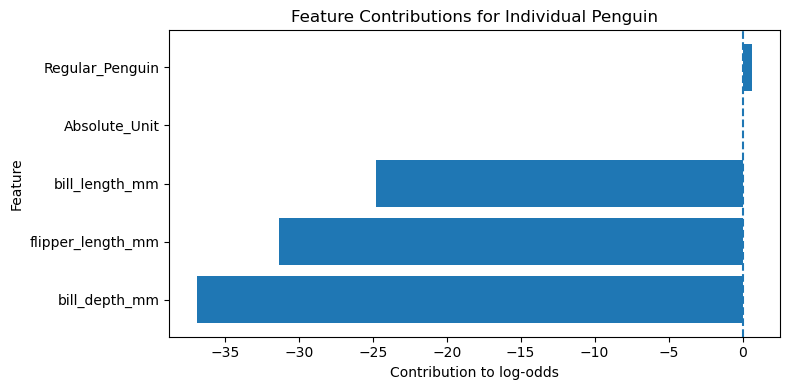

In [17]:
# Plot feature contributions, excluding the intercept for readability
feature_contributions = contributions.sort_values()

plt.figure(figsize=(8, 4))
plt.barh(
    feature_contributions.index,
    feature_contributions.values,
)
plt.axvline(0, linestyle="--")

plt.xlabel("Contribution to log-odds")
plt.ylabel("Feature")
plt.title("Feature Contributions for Individual Penguin")
plt.tight_layout()
plt.show()

## 10. Classification Performance

The predicted probabilities can be converted into classes using a threshold of 0.5.

The confusion matrix and standard classification metrics show how the model behaves when a probability prediction is turned into a binary decision.

In [18]:
# Generate probabilities and class predictions for all Chinstrap penguins
predicted_probabilities = result.predict(X_sm)
predicted_classes = (predicted_probabilities >= 0.5).astype(int)

# Calculate classification metrics
cm = confusion_matrix(y, predicted_classes)

print("Confusion Matrix:")
print(cm)

print("\nAccuracy:", accuracy_score(y, predicted_classes))
print("Precision:", precision_score(y, predicted_classes))
print("Recall:", recall_score(y, predicted_classes))
print("F1:", f1_score(y, predicted_classes))

Confusion Matrix:
[[32  2]
 [ 4 30]]

Accuracy: 0.9117647058823529
Precision: 0.9375
Recall: 0.8823529411764706
F1: 0.9090909090909091


## 11. ROC Curve and AUC

ROC-AUC evaluates **discrimination**: how well the model ranks positive observations above negative observations across classification thresholds.

An AUC of 0.5 corresponds to random ranking, while 1.0 represents perfect ranking.

The following result is a **training-set AUC**, so it should not be interpreted as an estimate of performance on unseen penguins.

AUC: 0.9740484429065743


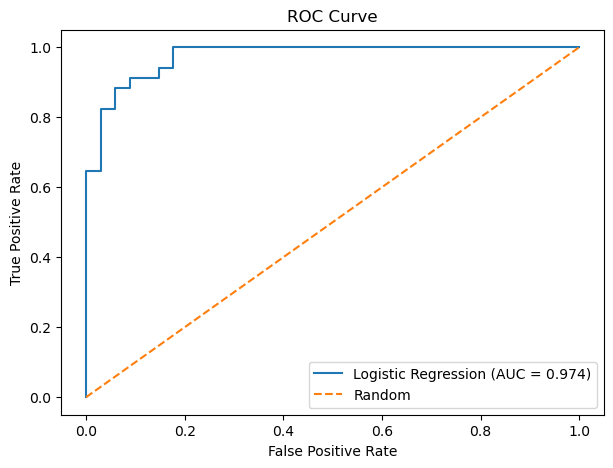

In [19]:
# Calculate the ROC curve and area under the curve
fpr, tpr, thresholds = roc_curve(y, predicted_probabilities)
auc = roc_auc_score(y, predicted_probabilities)

print("AUC:", auc)

plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc:.3f})",
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random",
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 12. Calibration

Discrimination and calibration answer different questions.

- **Discrimination:** Can the model rank female penguins above male penguins?
- **Calibration:** Do predicted probabilities correspond to observed frequencies?

A perfectly calibrated model would lie close to the diagonal line.

Mean predicted probability: [0.04596483 0.35216694 0.46370824 0.70842084 0.96946734]
Fraction of positives: [0.03448276 0.4        0.5        0.75       0.96428571]


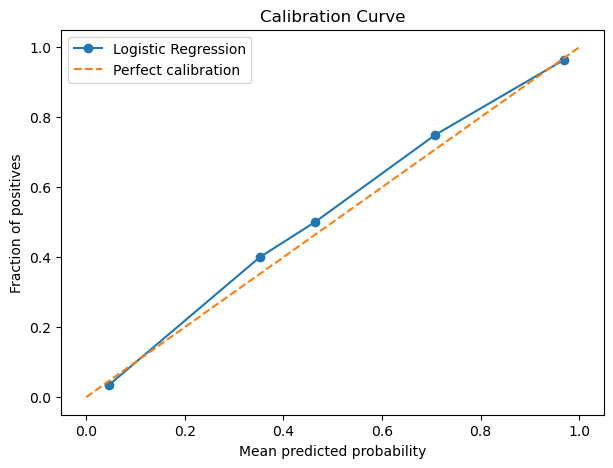

In [20]:
# Group predictions into five probability bins and compare
# mean predicted probability with the observed fraction of females
prob_true, prob_pred = calibration_curve(
    y,
    predicted_probabilities,
    n_bins=5,
)

print("Mean predicted probability:", prob_pred)
print("Fraction of positives:", prob_true)

plt.figure(figsize=(7, 5))
plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Logistic Regression",
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration",
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Curve")
plt.legend()
plt.show()

## 13. Brier Score

The Brier score summarizes the accuracy of predicted probabilities:

$$\text{Brier} = {\frac{1}{n}\sum_{i=1}^{n}(p_i-y_i)^2}$$

Lower values are better, with `0` representing perfect probability predictions.

As with the ROC-AUC and calibration curve above, this is calculated on the training observations and is therefore optimistic.

In [21]:
# Calculate the Brier score for the predicted probabilities
brier = brier_score_loss(y, predicted_probabilities)

print("Brier score:", brier)

Brier score: 0.06704858446314513


## 14. Conclusion and Limitations

This experiment shows why logistic regression is particularly interpretable:

- coefficients describe changes in **log-odds**
- exponentiated coefficients give **odds ratios**
- categorical effects can be interpreted relative to a reference category
- individual predictions can be decomposed into feature contributions
- the model directly produces probabilities

For this Chinstrap dataset, the fitted model produced a training-set **ROC-AUC of about 0.974** and a **Brier score of about 0.067**, while the calibration bins were reasonably close to the observed frequencies.

These results should be interpreted cautiously because the model was evaluated on the same observations used for training. A held-out test set or cross-validation would provide a better estimate of generalization.

The individual contribution plot above is a **model-inherent explanation from logistic regression**. It is **not LIME**; no local surrogate model is being fitted here.